In [1]:
import gzip
import pandas as pd
from collections import defaultdict

ibd_path = "lwk.refined_ibd.merged.ibd.gz"

In [2]:
total_autosomal_bp = 2_800_000_000  # ~2.8 Gb

In [3]:
def canonical_pair(iid1, iid2):
    return (iid1, iid2) if iid1 <= iid2 else (iid2, iid1)

def read_refined_ibd_segments(ibd_path, chrom_min=1, chrom_max=22, min_lod=None, min_bp=None):
    """
    Reads Refined IBD / merged-ibd-segments output.
    Returns a list of dict rows with canonical (A,B), chrom, start, end, lod.
    """
    rows = []
    with gzip.open(ibd_path, "rt") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.split()

            # Common column pattern:
            # id1 h1 id2 h2 chrom start end lod [extra...]
            if len(parts) < 8:
                continue

            id1, h1, id2, h2, chrom, start, end, lod = parts[:8]
            chrom = int(chrom)
            if chrom < chrom_min or chrom > chrom_max:
                continue

            iid1 = id1.split("_")[0]
            iid2 = id2.split("_")[0]
            A, B = canonical_pair(iid1, iid2)

            s = int(start); e = int(end)
            if e < s:
                s, e = e, s

            lod = float(lod)
            if (min_lod is not None) and (lod < min_lod):
                continue
                
            if (min_bp is not None) and ((e - s + 1) < min_bp):
                continue

            rows.append({"A": A, "B": B, "chrom": chrom, "start": s, "end": e, "lod": lod})
    return rows

def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals. intervals: list[(s,e)]"""
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1] + 1:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]

In [4]:
def summarize_pairs(segments, total_autosomal_bp):
    # Collect raw lengths + per-pair per-chrom intervals for union coverage
    pair_chrom_intervals = defaultdict(lambda: defaultdict(list))
    pair_raw_lens = defaultdict(list)
    pair_lods = defaultdict(list)

    for r in segments:
        A, B = r["A"], r["B"]
        chrom = r["chrom"]
        s, e = r["start"], r["end"]
        pair_chrom_intervals[(A, B)][chrom].append((s, e))
        pair_raw_lens[(A, B)].append(e - s + 1)
        pair_lods[(A, B)].append(r["lod"])

    rows = []
    for (A, B), chrom_dict in pair_chrom_intervals.items():
        raw_lens = pair_raw_lens[(A, B)]

        # merged union bp across chroms
        merged_bp = 0
        for chrom, intervals in chrom_dict.items():
            merged = merge_intervals(intervals)
            merged_bp += sum(e - s + 1 for s, e in merged)

        total_bp_raw = sum(raw_lens)
        total_mb_merged = merged_bp / 1e6

        # PI_HAT ≈ (shared genome proportion) = (IBD1/2 contributions)
        # Using total shared Mb as a proxy: (total_mb / 2) / 3400
        pihat_like_mb = (total_mb_merged / 2.0) / 3400.0

        rows.append({
            "A": A,
            "B": B,
            "nseg_raw": len(raw_lens),
            "total_bp_raw": total_bp_raw,
            "total_bp_merged": merged_bp,
            "total_mb_merged": total_mb_merged,
            "mean_seg_mb_raw": (total_bp_raw / len(raw_lens)) / 1e6 if raw_lens else 0.0,
            "max_seg_mb_raw": (max(raw_lens) / 1e6) if raw_lens else 0.0,
            "mean_lod": sum(pair_lods[(A, B)]) / len(pair_lods[(A, B)]),
            "max_lod": max(pair_lods[(A, B)]),
            "pihat_like_mb": pihat_like_mb,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["total_mb_merged", "nseg_raw"], ascending=False).reset_index(drop=True)
    return df

In [5]:
segs = read_refined_ibd_segments(ibd_path, min_lod=None, min_bp=None)  # can try different min_lod and min_dp later
pair_stats = summarize_pairs(segs, total_autosomal_bp)

pair_stats.head(30)

,A,B,nseg_raw,total_bp_raw,total_bp_merged,total_mb_merged,mean_seg_mb_raw,max_seg_mb_raw,mean_lod,max_lod,pihat_like_mb
0,NA19396,NA19397,257,1468666390,1468666390,1468.666390,5.714655,66.132712,59.485759,573.88,0.215980
1,NA19443,NA19470,265,1453740420,1453740420,1453.740420,5.485813,63.045315,49.076528,549.75,0.213785
2,NA19331,NA19334,231,1396209333,1396209333,1396.209333,6.044196,96.961685,55.658398,737.19,0.205325
3,NA19347,NA19352,243,1385001467,1385001467,1385.001467,5.699595,97.266672,45.662222,419.16,0.203677
4,NA19434,NA19444,243,1353065474,1353065474,1353.065474,5.568171,61.296844,53.472263,698.20,0.198980
5,NA19381,NA19382,414,1316977196,1316977196,1316.977196,3.181104,31.558513,24.790145,108.47,0.193673
6,NA19445,NA19453,426,1297921203,1297921203,1297.921203,3.046763,22.778724,25.052300,136.34,0.190871
7,NA19313,NA19331,419,1260642037,1260642037,1260.642037,3.008692,28.836875,22.977589,96.60,0.185389
8,NA19373,NA19374,201,1258612092,1258612092,1258.612092,6.261752,57.460843,69.206716,673.70,0.185090
9,NA19469,NA19470,418,1246050868,1246050868,1246.050868,2.980983,26.567734,22.888684,118.43,0.183243


In [6]:
top_relatives = pair_stats.sort_values("total_mb_merged", ascending=False).head(30)
top_relatives[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw","mean_lod","max_lod","pihat_like_mb"]]

,A,B,total_mb_merged,nseg_raw,max_seg_mb_raw,mean_lod,max_lod,pihat_like_mb
0,NA19396,NA19397,1468.666390,257,66.132712,59.485759,573.88,0.215980
1,NA19443,NA19470,1453.740420,265,63.045315,49.076528,549.75,0.213785
2,NA19331,NA19334,1396.209333,231,96.961685,55.658398,737.19,0.205325
3,NA19347,NA19352,1385.001467,243,97.266672,45.662222,419.16,0.203677
4,NA19434,NA19444,1353.065474,243,61.296844,53.472263,698.20,0.198980
5,NA19381,NA19382,1316.977196,414,31.558513,24.790145,108.47,0.193673
6,NA19445,NA19453,1297.921203,426,22.778724,25.052300,136.34,0.190871
7,NA19313,NA19331,1260.642037,419,28.836875,22.977589,96.60,0.185389
8,NA19373,NA19374,1258.612092,201,57.460843,69.206716,673.70,0.185090
9,NA19469,NA19470,1246.050868,418,26.567734,22.888684,118.43,0.183243


In [7]:
# Close relatives: sort top 1% by total_mb_merged
close = pair_stats[pair_stats["total_mb_merged"] > pair_stats["total_mb_merged"].quantile(0.99)]

# Among close, a heuristic rough split by segment pattern:
# (fewer segments overlapping & huge max segment length) often looks parent/child-ish in ideal conditions.
# (more segments overlapping & small max segment length) often looks sibling-ish;

med_nseg = close["nseg_raw"].median()
pc_like = close[(close["max_seg_mb_raw"] > 40) & (close["nseg_raw"] < med_nseg)]
sib_like = close[(close["max_seg_mb_raw"] <= 40) & (close["nseg_raw"] >= med_nseg)]

pc_like[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10), \
sib_like[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10)

(          A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 21  NA19376  NA19397       257.519420        75       42.621760
 24  NA19318  NA19376       240.491965        48       48.544464
 27  NA19376  NA19396       226.742558        58       41.188596,
           A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 5   NA19381  NA19382      1316.977196       414       31.558513
 6   NA19445  NA19453      1297.921203       426       22.778724
 7   NA19313  NA19331      1260.642037       419       28.836875
 9   NA19469  NA19470      1246.050868       418       26.567734
 10  NA19380  NA19382       916.676275       260       19.497371
 11  NA19444  NA19453       858.125817       245       33.338225
 12  NA19434  NA19453       638.365336       193       28.065341
 13  NA19380  NA19381       619.410077       164       20.665000
 14  NA19313  NA19334       618.749065       217       28.836875
 15  NA19443  NA19469       599.213861       198       26.567734)

In [8]:
# Ablation: threshold 30
pc_like_30 = close[(close["max_seg_mb_raw"] > 30) & (close["nseg_raw"] < med_nseg)]
sib_like_30 = close[(close["max_seg_mb_raw"] <= 30) & (close["nseg_raw"] >= med_nseg)]

pc_like_30[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10), \
sib_like_30[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10)

(          A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 20  NA19375  NA19376       284.662349        69       31.306141
 21  NA19376  NA19397       257.519420        75       42.621760
 24  NA19318  NA19376       240.491965        48       48.544464
 27  NA19376  NA19396       226.742558        58       41.188596,
           A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 6   NA19445  NA19453      1297.921203       426       22.778724
 7   NA19313  NA19331      1260.642037       419       28.836875
 9   NA19469  NA19470      1246.050868       418       26.567734
 10  NA19380  NA19382       916.676275       260       19.497371
 12  NA19434  NA19453       638.365336       193       28.065341
 13  NA19380  NA19381       619.410077       164       20.665000
 14  NA19313  NA19334       618.749065       217       28.836875
 15  NA19443  NA19469       599.213861       198       26.567734
 16  NA19355  NA19444       363.210159       120       26.996121
 18  NA19309  NA19359   

In [9]:
# Ablation: threshold 35
pc_like_35 = close[(close["max_seg_mb_raw"] > 35) & (close["nseg_raw"] < med_nseg)]
sib_like_35 = close[(close["max_seg_mb_raw"] <= 35) & (close["nseg_raw"] >= med_nseg)]

pc_like_35[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10), \
sib_like_35[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10)

(          A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 21  NA19376  NA19397       257.519420        75       42.621760
 24  NA19318  NA19376       240.491965        48       48.544464
 27  NA19376  NA19396       226.742558        58       41.188596,
           A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 5   NA19381  NA19382      1316.977196       414       31.558513
 6   NA19445  NA19453      1297.921203       426       22.778724
 7   NA19313  NA19331      1260.642037       419       28.836875
 9   NA19469  NA19470      1246.050868       418       26.567734
 10  NA19380  NA19382       916.676275       260       19.497371
 11  NA19444  NA19453       858.125817       245       33.338225
 12  NA19434  NA19453       638.365336       193       28.065341
 13  NA19380  NA19381       619.410077       164       20.665000
 14  NA19313  NA19334       618.749065       217       28.836875
 15  NA19443  NA19469       599.213861       198       26.567734)

In [10]:
# Ablation: threshold 45
pc_like_45 = close[(close["max_seg_mb_raw"] > 45) & (close["nseg_raw"] < med_nseg)]
sib_like_45 = close[(close["max_seg_mb_raw"] <= 45) & (close["nseg_raw"] >= med_nseg)]

pc_like_45[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10), \
sib_like_45[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10)

(          A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 24  NA19318  NA19376       240.491965        48       48.544464,
           A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 5   NA19381  NA19382      1316.977196       414       31.558513
 6   NA19445  NA19453      1297.921203       426       22.778724
 7   NA19313  NA19331      1260.642037       419       28.836875
 9   NA19469  NA19470      1246.050868       418       26.567734
 10  NA19380  NA19382       916.676275       260       19.497371
 11  NA19444  NA19453       858.125817       245       33.338225
 12  NA19434  NA19453       638.365336       193       28.065341
 13  NA19380  NA19381       619.410077       164       20.665000
 14  NA19313  NA19334       618.749065       217       28.836875
 15  NA19443  NA19469       599.213861       198       26.567734)

In [11]:
# Ablation: threshold 50
pc_like_50 = close[(close["max_seg_mb_raw"] > 50) & (close["nseg_raw"] < med_nseg)]
sib_like_50 = close[(close["max_seg_mb_raw"] <= 50) & (close["nseg_raw"] >= med_nseg)]

pc_like_50[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10), \
sib_like_50[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10)

(Empty DataFrame
 Columns: [A, B, total_mb_merged, nseg_raw, max_seg_mb_raw]
 Index: [],
           A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 5   NA19381  NA19382      1316.977196       414       31.558513
 6   NA19445  NA19453      1297.921203       426       22.778724
 7   NA19313  NA19331      1260.642037       419       28.836875
 9   NA19469  NA19470      1246.050868       418       26.567734
 10  NA19380  NA19382       916.676275       260       19.497371
 11  NA19444  NA19453       858.125817       245       33.338225
 12  NA19434  NA19453       638.365336       193       28.065341
 13  NA19380  NA19381       619.410077       164       20.665000
 14  NA19313  NA19334       618.749065       217       28.836875
 15  NA19443  NA19469       599.213861       198       26.567734)

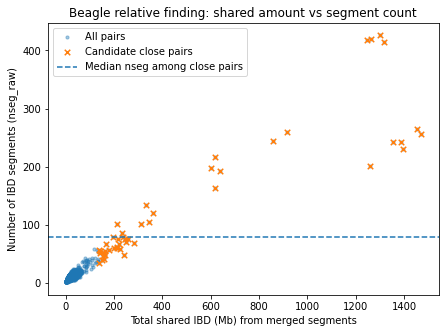

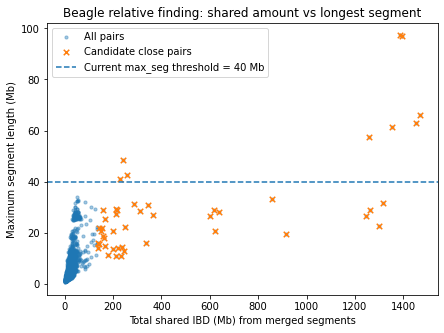

In [12]:
import matplotlib.pyplot as plt

# Plot 1: total shared Mb vs number of segments
plt.figure(figsize=(7, 5))
plt.scatter(pair_stats["total_mb_merged"], pair_stats["nseg_raw"], s=10, alpha=0.4, label="All pairs")
plt.scatter(close["total_mb_merged"], close["nseg_raw"], s=30, marker="x", label="Candidate close pairs")
plt.axhline(med_nseg, linestyle="--", label="Median nseg among close pairs")
plt.xlabel("Total shared IBD (Mb) from merged segments")
plt.ylabel("Number of IBD segments (nseg_raw)")
plt.title("Beagle relative finding: shared amount vs segment count")
plt.legend()
plt.show()

# Plot 2: total shared Mb vs max segment
plt.figure(figsize=(7, 5))
plt.scatter(pair_stats["total_mb_merged"], pair_stats["max_seg_mb_raw"], s=10, alpha=0.4, label="All pairs")
plt.scatter(close["total_mb_merged"], close["max_seg_mb_raw"], s=30, marker="x", label="Candidate close pairs")
plt.axhline(40, linestyle="--", label="Current max_seg threshold = 40 Mb")
plt.xlabel("Total shared IBD (Mb) from merged segments")
plt.ylabel("Maximum segment length (Mb)")
plt.title("Beagle relative finding: shared amount vs longest segment")
plt.legend()
plt.show()

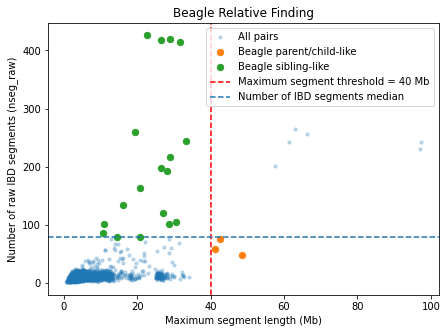

In [13]:
plt.figure(figsize=(7, 5))

# all pairs in background
plt.scatter(
    pair_stats["max_seg_mb_raw"],
    pair_stats["nseg_raw"],
    s=10,
    alpha=0.25,
    label="All pairs"
)

# Beagle parent/child-like
pc_like = close[(close["max_seg_mb_raw"] > 40) & (close["nseg_raw"] < med_nseg)]
plt.scatter(
    pc_like["max_seg_mb_raw"],
    pc_like["nseg_raw"],
    s=40,
    marker="o",
    label="Beagle parent/child-like"
)

# Beagle sibling-like
sib_like = close[(close["max_seg_mb_raw"] <= 40) & (close["nseg_raw"] >= med_nseg)]
plt.scatter(
    sib_like["max_seg_mb_raw"],
    sib_like["nseg_raw"],
    s=40,
    marker="o",
    label="Beagle sibling-like"
)

plt.axvline(40, linestyle="--", color="red", label="Maximum segment threshold = 40 Mb")
plt.axhline(med_nseg, linestyle="--", label="Number of IBD segments median")

plt.xlabel("Maximum segment length (Mb)")
plt.ylabel("Number of raw IBD segments (nseg_raw)")
plt.title("Beagle Relative Finding")
plt.legend()
plt.show()

In [14]:
# Nearby ablation for max_seg_mb_raw threshold
thresholds = [30, 35, 40, 45, 50]

# PLINK reference pairs
plink_pc_pairs = {
    tuple(["NA19313", "NA19331"]),
    tuple(["NA19381", "NA19382"]),
    tuple(["NA19445", "NA19453"]),
    tuple(["NA19469", "NA19470"])
}

plink_sib_pairs = {
    tuple(["NA19331", "NA19334"]),
    tuple(["NA19347", "NA19352"]),
    tuple(["NA19373", "NA19374"]),
    tuple(["NA19396", "NA19397"]),
    tuple(["NA19434", "NA19444"]),
    tuple(["NA19443", "NA19470"])
}

pc_counts = []
sib_counts = []
pc_overlap = []
sib_overlap = []
total_overlap = []

for t in thresholds:
    pc_like_t = close[(close["max_seg_mb_raw"] > t) & (close["nseg_raw"] < med_nseg)]
    sib_like_t = close[(close["max_seg_mb_raw"] <= t) & (close["nseg_raw"] >= med_nseg)]

    pc_pairs_t = set(tuple(sorted([a, b])) for a, b in zip(pc_like_t["A"], pc_like_t["B"]))
    sib_pairs_t = set(tuple(sorted([a, b])) for a, b in zip(sib_like_t["A"], sib_like_t["B"]))

    pc_counts.append(len(pc_pairs_t))
    sib_counts.append(len(sib_pairs_t))
    pc_overlap.append(len(pc_pairs_t & plink_pc_pairs))
    sib_overlap.append(len(sib_pairs_t & plink_sib_pairs))
    total_overlap.append(len((pc_pairs_t | sib_pairs_t) & (plink_pc_pairs | plink_sib_pairs)))

ablation_df = pd.DataFrame({
    "threshold_mb": thresholds,
    "beagle_pc_like_calls": pc_counts,
    "beagle_sib_like_calls": sib_counts,
    "plink_pc_overlap": pc_overlap,
    "plink_sib_overlap": sib_overlap,
    "total_plink_overlap": total_overlap
})

ablation_df

,threshold_mb,beagle_pc_like_calls,beagle_sib_like_calls,plink_pc_overlap,plink_sib_overlap,total_plink_overlap
0,30,4,15,0,0,3
1,35,3,18,0,0,4
2,40,3,18,0,0,4
3,45,1,18,0,0,4
4,50,0,18,0,0,4


In [15]:
# Robustness on LOD
lod_thresholds = [None, 1, 3, 5]
min_seg_thresholds_mb = [0, 1, 3, 5]

robustness_rows = []
robustness_pair_sets = {}

for lod in lod_thresholds:
    for min_seg_mb in min_seg_thresholds_mb:
        segs = read_refined_ibd_segments(
            ibd_path,
            min_lod=lod,
            min_bp=int(min_seg_mb * 1_000_000)
        )

        pair_stats = summarize_pairs(segs, total_autosomal_bp)
        close = pair_stats[pair_stats["total_mb_merged"] > pair_stats["total_mb_merged"].quantile(0.99)]

        pc_like = close[(close["max_seg_mb_raw"] > 40) & (close["nseg_raw"] < med_nseg)]
        sib_like = close[(close["max_seg_mb_raw"] <= 40) & (close["nseg_raw"] >= med_nseg)]

        pc_pairs = set(tuple(sorted([a, b])) for a, b in zip(pc_like["A"], pc_like["B"]))
        sib_pairs = set(tuple(sorted([a, b])) for a, b in zip(sib_like["A"], sib_like["B"]))

        lod_label = "none" if lod is None else str(lod)
        robustness_pair_sets[(lod_label, min_seg_mb)] = close

        robustness_rows.append({
            "lod": lod_label,
            "min_seg_mb": min_seg_mb,
            "pairs_detected": len(pair_stats),
            "candidate_close_pairs": len(close),
            "beagle_pc_like_calls": len(pc_pairs),
            "beagle_sib_like_calls": len(sib_pairs),
            "plink_pc_overlap": len(pc_pairs & plink_pc_pairs),
            "plink_sib_overlap": len(sib_pairs & plink_sib_pairs),
            "total_plink_overlap": len((pc_pairs | sib_pairs) & (plink_pc_pairs | plink_sib_pairs))
        })

robustness_df = pd.DataFrame(robustness_rows)
robustness_df 

,lod,min_seg_mb,pairs_detected,candidate_close_pairs,beagle_pc_like_calls,beagle_sib_like_calls,plink_pc_overlap,plink_sib_overlap,total_plink_overlap
0,none,0,4655,47,3,18,0,0,4
1,none,1,4651,47,3,14,0,0,4
2,none,3,3239,33,4,6,0,0,5
3,none,5,1356,14,6,0,0,0,6
4,1,0,4655,47,3,18,0,0,4
5,1,1,4651,47,3,14,0,0,4
6,1,3,3239,33,4,6,0,0,5
7,1,5,1356,14,6,0,0,0,6
8,3,0,4655,47,3,18,0,0,4
9,3,1,4651,47,3,14,0,0,4
